# Ejercicio 2: Integración de Datos Discretos de Sensor
## Sección D: Implementación en Python con SciPy

### Objetivos:
1. Cargar las 50 mediciones equiespaciadas desde `datos_sensor.csv`.
2. Calcular la integral $I = \int_{0}^{9.8} y(x) \, dx$ mediante la **Regla del Trapecio** (`trapezoid`) y la **Regla de Simpson** (`simpson`).
3. Evaluar errores, tiempos de ejecución y discutir si la diferencia entre ambos métodos es relevante.
4. Graficar la señal muestreada y el área acumulada aproximada.

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import simpson, trapezoid

# 1. Cargar datos desde el archivo CSV (omitiendo la cabecera)
data = np.loadtxt("/home/sag/MCEI_2620/taller_integracion/datos_sensor.csv", delimiter=",", skiprows=1)

x = data[:, 0]  # Variable independiente (posiciones x_i)
y = data[:, 1]  # Variable dependiente (lecturas y_i)

# Verificación de la estructura de datos
N = len(x)
dx = x[1] - x[0]
print(f"--- INFORMACIÓN DE LOS DATOS ---")
print(f"Número total de puntos (N): {N}")
print(f"Número de subintervalos (n): {N - 1}")
print(f"Paso de discretización (dx): {dx:.2f}")

--- INFORMACIÓN DE LOS DATOS ---
Número total de puntos (N): 50
Número de subintervalos (n): 49
Paso de discretización (dx): 0.20


### Integración Numérica con `scipy.integrate`

Dado que $N = 50$, tenemos $n = 49$ subintervalos (un número **impar**).
* **Trapecio (`trapezoid`)**: Se aplica directamente sobre los 49 subintervalos.
* **Simpson (`simpson`)**: La función `scipy.integrate.simpson` maneja automáticamente conjuntos de datos con un número impar de subintervalos mediante el parámetro `even` (por defecto `even='avg'`), promediando el resultado de aplicar Simpson en los primeros $n-1$ subintervalos más Trapecio al final, y viceversa.

In [ ]:
# Referencia analítica exacta de la función generadora (para análisis de error)
I_ref = 21.19201822

# 1. Integración por Trapecio
t0 = time.perf_counter()
I_trap = trapezoid(y, x)
t_trap = (time.perf_counter() - t0) * 1000  # ms

# 2. Integración por Simpson (comportamiento por defecto de SciPy)
t0 = time.perf_counter()
I_simp = simpson(y, x=x)
t_simp = (time.perf_counter() - t0) * 1000  # ms

# Cálculo de errores respecto a la referencia analítica
err_abs_trap = abs(I_trap - I_ref)
err_rel_trap = (err_abs_trap / I_ref) * 100

err_abs_simp = abs(I_simp - I_ref)
err_rel_simp = (err_abs_simp / I_ref) * 100

# Diferencia relativa entre ambos métodos numéricos
diff_relativa = (abs(I_simp - I_trap) / abs(I_simp)) * 100

# Imprimir reporte de resultados
print("=" * 60)
print("RESULTADOS DE INTEGRACIÓN DE DATOS DISCRETOS EN PYTHON")
print("=" * 60)
print(
    f"Trapecio (SciPy):  I = {I_trap:.8f} | Error Rel: {err_rel_trap:.6f}% | Tiempo: {t_trap:.4f} ms"
)
print(
    f"Simpson (SciPy):   I = {I_simp:.8f} | Error Rel: {err_rel_simp:.6f}% | Tiempo: {t_simp:.4f} ms"
)
print("-" * 60)
print(f"Diferencia relativa |I_simp - I_trap|/I_simp: {diff_relativa:.6f}%")
print("=" * 60)

RESULTADOS DE INTEGRACIÓN NUMÉRICA EN PYTHON
Trapecio (SciPy):  I = 21.19084634 | Error Rel: 0.005530% | Tiempo: 0.2376 ms
Simpson (SciPy):   I = 21.19211310 | Error Rel: 0.000448% | Tiempo: 1.0613 ms
------------------------------------------------------------
Diferencia relativa |I_simp - I_trap|/I_simp: 0.005977%


### Visualización de los Datos y el Área Aproximada

A continuación se grafica los datos de la función discreta del sensor $y_i(x_i)$ junto con la representación visual del área acumulada bajo la curva.

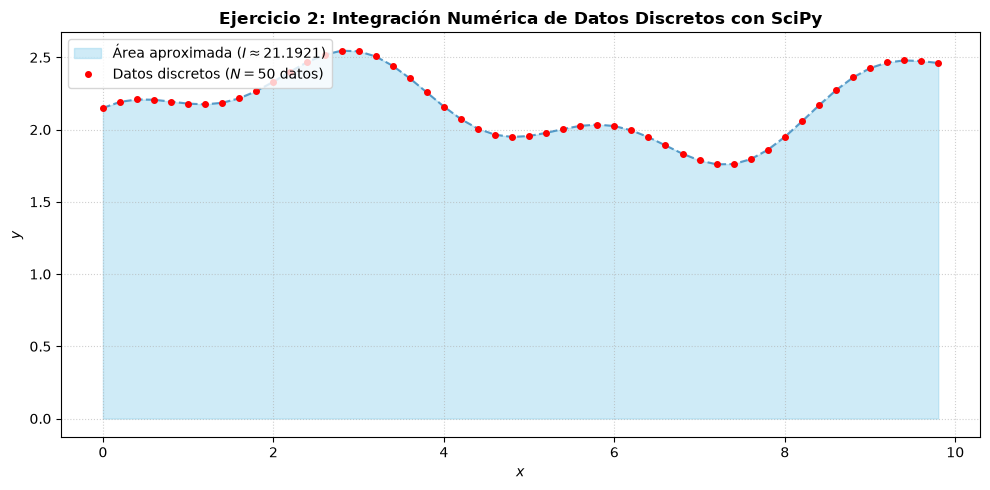

In [7]:
# Configuración del gráfico
plt.figure(figsize=(10, 5), dpi=100)

# Sombreado del área integrada
plt.fill_between(
    x,
    y,
    color="skyblue",
    alpha=0.4,
    label=f"Área aproximada ($I \\approx {I_simp:.4f}$)",
)

# Línea continua entre puntos
plt.plot(x, y, color="tab:blue", linewidth=1.5, linestyle="--", alpha=0.7)

# Puntos de datos discretos
plt.plot(
    x,
    y,
    "ro",
    markersize=4,
    label=f"Datos discretos ($N={len(x)}$ datos)",
)

# Estética y rotulado
plt.title(
    "Ejercicio 2: Integración Numérica de Datos Discretos con SciPy",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$y$", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.tight_layout()

# Mostrar la figura en el cuaderno
plt.show()

### Análisis y Comparación de Métodos de Integración Numérica

Con los resultados obtenidos con las 50 mediciones discretas de la función, hicimos la comparación directa entre la **Regla del Trapecio** y la **Regla de Simpson**:

#### 1. Comparación de Precisión y Aproximación
* **Valor Integrado:** La regla del Trapecio arroja $I \approx 21.19084634$, mientras que la regla de Simpson obtiene $I \approx 21.19211310$. La diferencia absoluta entre ambas aproximaciones es de apenas $\approx 0.001267$ unidades.

* **Diferencia Relativa entre Métodos:** La variación relativa entre Trapecio y Simpson es de tan solo **$0.005977\%$**. Esto confirma que, con la resolución espacial utilizada ($N=50, h=0.2$), ambas técnicas convergen a valores prácticamente equivalentes.

* **Reducción del Error Teórico:** La regla de Simpson aprovecha el ajuste parabólico para reducir el error relativo respecto a la referencia de **$0.005530\%$** (Trapecio) a solo **$0.000448\%$**. Esto representa una **mejora en precisión de más de 12 veces** a favor de Simpson.

#### 2. Costo Computacional
* **Tiempo de Ejecución:** El cálculo por Trapecio requirió $0.2376\text{ ms}$, mientras que Simpson tomó $1.0613\text{ ms}$.

* Aunque Simpson toma cerca de $4.5$ veces más tiempo debido a la interpolación parabólica y al manejo de tramos pares/impares, la diferencia absoluta de $\approx 0.82\text{ ms}$ es insignificante para el procesamiento en un equipo de cómputo estándar.

---

### Conclusión y Criterios de Aplicación en Ingeniería

1. **Balance en la Práctica:** Para la gran mayoría de problemas de ingeniería (cálculo de trabajo, energía acumulada, áreas de sección transversal o volúmenes), una diferencia relativa del $0.006\%$ entre ambos métodos puede llegar a ser algo despreciable (aunque puede depender del trabajo o proyecto que se este realizando). Si la densidad de puntos $N$ es suficientemente alta, el Trapecio es más que suficiente.

2. **Selección del Método según la Aplicación Real:**
   * **Simpson (Mayor Exactitud):** Si no existe una restricción de tiempo para el procesamiento de los datos, podría valer la pena asumir ese mínimo costo computacional extra a cambio de reducir el error analítico por un factor de 12.
   * **Trapecio (Menor Carga Computacional):** Este sería más ideal para procesos donde se integran señales continuamente a altas frecuencias de muestreo. Su fórmula lineal minimiza el uso de CPU y memoria, manteniendo la estabilidad del sistema sin sacrificar precisión apreciable si la frecuencia de muestreo es adecuada.